# PDF analysis

Here I am interested in the PDF studies that Mingshu has performed in his turbulent BEC experiments.  The basic challenge is to take the observed pdf (with fat wings) and separate that from the also measured pdf for a BEC alone.

In [6]:
import PyPlot as plt
import FFTW
import Random
import Statistics as Stat
import StatsBase
using LaTeXStrings
using LsqFit
using NPZ
using DSP

In [7]:
# A simple gauss model
@. gauss_model(x, p) = p[1] * exp(-(((x - p[2]) / p[3])^2) / 2)

"""
A callable struct to implement a Julia equivalent of a closure

This makes a Guass*poly of order 
"""
struct Gauss
    order::Int64
end

function (a::Gauss)(x, p)
    ans = ones(Float64, size(x))

    for n in 1:a.order
        ans .+= p[n+3] .* x .^ n
    end

    return ans .* gauss_model(x, p)
end

## Import the data

In [8]:
v_bec = npzread("pdf_BEC_list_long.npy") # Mislabeled
# v_bec = npzread("pdf_BEC_list_long0.npy");

println(length(v_bec))

v_bec_hist = Stat.normalize(StatsBase.fit(StatsBase.Histogram, v_bec, range(-5.39, 5.39, 50)))

1770


StatsBase.Histogram{Float64, 1, Tuple{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}}
edges:
  -5.39:0.22:5.39
weights: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
closed: left
isdensity: true

In [9]:
# From Mingshu directly (Old data)
v_bec_hist_data =[0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.004329,
    0.01298701, 0.02164502, 0.04329004, 0.0995671, 0.19480519,
    0.29004329, 0.49350649, 0.75324675, 0.94805195, 1.0,
    0.99134199, 0.92640693, 0.65800866, 0.51082251, 0.33333333,
    0.21212121, 0.08658009, 0.05627706, 0.01731602, 0.0,
    0.00865801, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0]

v_bec_hist_x = [-5.39, -5.17, -4.95, -4.73, -4.51, -4.29, -4.07, -3.85, -3.63,
    -3.41, -3.19, -2.97, -2.75, -2.53, -2.31, -2.09, -1.87, -1.65,
    -1.43, -1.21, -0.99, -0.77, -0.55, -0.33, -0.11, 0.11, 0.33,
    0.55, 0.77, 0.99, 1.21, 1.43, 1.65, 1.87, 2.09, 2.31,
    2.53, 2.75, 2.97, 3.19, 3.41, 3.63, 3.85, 4.07, 4.29,
    4.51, 4.73, 4.95, 5.17, 5.39]

v_turb_hist_data =[0.0, 0.0, 0.00123153, 0.0, 0.0,
    0.0, 0.00123153, 0.00492611, 0.00369458, 0.00615764,
    0.01108374, 0.01724138, 0.0270936, 0.05418719, 0.091133,
    0.13054187, 0.20812808, 0.31034483, 0.38054187, 0.50738916,
    0.64162562, 0.84359606, 0.87931034, 1.0, 0.97783251,
    0.93965517, 0.89655172, 0.72044335, 0.62192118, 0.46305419,
    0.32389163, 0.22906404, 0.16871921, 0.11699507, 0.08251232,
    0.05541872, 0.03817734, 0.01600985, 0.02339901, 0.00862069,
    0.00369458, 0.00246305, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0]


v_turb_hist_x = [-5.39, -5.17, -4.95, -4.73, -4.51, -4.29, -4.07, -3.85, -3.63,
    -3.41, -3.19, -2.97, -2.75, -2.53, -2.31, -2.09, -1.87, -1.65,
    -1.43, -1.21, -0.99, -0.77, -0.55, -0.33, -0.11, 0.11, 0.33,
    0.55, 0.77, 0.99, 1.21, 1.43, 1.65, 1.87, 2.09, 2.31,
    2.53, 2.75, 2.97, 3.19, 3.41, 3.63, 3.85, 4.07, 4.29,
    4.51, 4.73, 4.95, 5.17, 5.39];

v_bec_hist_data ./= sum(v_bec_hist_data)

v_turb_hist_data ./= sum(v_turb_hist_data);

In [10]:
# From Mingshu directly (New data)
v_bec_hist_data = [0.        ,0.        ,0.        ,0.        ,0.        ,0.        ,
 0.        ,0.        ,0.        ,0.        ,0.        ,0.0173913 ,
 0.02173913,0.08695652,0.20869565,0.31304348,0.55652174,0.71304348,
 0.86956522,0.96521739,1.        ,0.73913043,0.52608696,0.31304348,
 0.1826087 ,0.1173913 ,0.02608696,0.0173913 ,0.00434783,0.        ,
 0.        ,0.        ,0.        ,0.        ,0.        ,0.        ,
 0.        ,0.        ,0.        ]

v_bec_hist_x = [-3.89743590e+00,-3.69230769e+00,-3.48717949e+00,-3.28205128e+00,
 -3.07692308e+00,-2.87179487e+00,-2.66666667e+00,-2.46153846e+00,
 -2.25641026e+00,-2.05128205e+00,-1.84615385e+00,-1.64102564e+00,
 -1.43589744e+00,-1.23076923e+00,-1.02564103e+00,-8.20512821e-01,
 -6.15384615e-01,-4.10256410e-01,-2.05128205e-01,-2.22044605e-16,
  2.05128205e-01, 4.10256410e-01, 6.15384615e-01, 8.20512821e-01,
  1.02564103e+00, 1.23076923e+00, 1.43589744e+00, 1.64102564e+00,
  1.84615385e+00, 2.05128205e+00, 2.25641026e+00, 2.46153846e+00,
  2.66666667e+00, 2.87179487e+00, 3.07692308e+00, 3.28205128e+00,
  3.48717949e+00, 3.69230769e+00, 3.89743590e+00]

  v_turb_hist_data = [0.        ,0.        ,0.00103199,0.        ,0.00103199,0.00309598,
  0.00309598,0.00722394,0.01444788,0.01341589,0.02579979,0.06088751,
  0.11351909,0.20743034,0.29411765,0.44891641,0.61506708,0.78534572,
  0.87822497,1.        ,0.86687307,0.79876161,0.6749226 ,0.45201238,
  0.33642931,0.23013416,0.18472652,0.10629515,0.05469556,0.03508772,
  0.01547988,0.01651187,0.00928793,0.00412797,0.00825593,0.        ,
  0.00103199,0.00103199,0.        ]
 
 v_turb_hist_x = [-3.89743590e+00,-3.69230769e+00,-3.48717949e+00,-3.28205128e+00,
  -3.07692308e+00,-2.87179487e+00,-2.66666667e+00,-2.46153846e+00,
  -2.25641026e+00,-2.05128205e+00,-1.84615385e+00,-1.64102564e+00,
  -1.43589744e+00,-1.23076923e+00,-1.02564103e+00,-8.20512821e-01,
  -6.15384615e-01,-4.10256410e-01,-2.05128205e-01,-2.22044605e-16,
   2.05128205e-01, 4.10256410e-01, 6.15384615e-01, 8.20512821e-01,
   1.02564103e+00, 1.23076923e+00, 1.43589744e+00, 1.64102564e+00,
   1.84615385e+00, 2.05128205e+00, 2.25641026e+00, 2.46153846e+00,
   2.66666667e+00, 2.87179487e+00, 3.07692308e+00, 3.28205128e+00,
   3.48717949e+00, 3.69230769e+00, 3.89743590e+00] 

v_bec_hist_data ./= sum(v_bec_hist_data)

v_turb_hist_data ./= sum(v_turb_hist_data);

In [11]:
# Workout the number of data point that must have been used for the turb data set

w =1 / minimum( [d for d in v_turb_hist_data if d > 0] )

8012.013536952877

## Simple fit and deconv.

In [12]:
# Fit turbulant data to poly gauss_model
gauss_model_bec = Gauss(0)

p0 = [1.1, 0.0, 1.0, 0.0, 0.0]
lb = [0.1, -0.5, 0.01, -1, -1]
ub = [10.0, 0.5, 10, 1.0, 1.0]

p0 = [1.1, 0.0, 1.0]
lb = [0.1, -0.5, 0.01]
ub = [10.0, 0.5, 10]

# There are 1770 points in the BEC dataset
n = 1770.0
w_bec = [(d * n  + 1 )^-0.5 for d in v_bec_hist_data] .* n
bec_fit = LsqFit.curve_fit(gauss_model_bec, v_bec_hist_x, v_bec_hist_data, w_bec, p0, lower=lb, upper=ub);

# Fit turbulant data to poly gauss_model
gauss_model_turb = Gauss(6)
p0 = [1.1, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
lb = [0.1, -0.5, 0.01, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]
ub = [10.0, 0.5, 10, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

# There are 8776 points in the turb dataset
n = 8012 # 8776.0
w_turb = [(n * d + 1)^-0.5 for d in v_turb_hist_data] .* n
turb_fit = LsqFit.curve_fit(gauss_model_turb, v_turb_hist_x, v_turb_hist_data, w_turb, p0, lower=lb, upper=ub);

In [13]:
display(LsqFit.coef(bec_fit))
display(LsqFit.coef(turb_fit))


3-element Vector{Float64}:
 0.14611227224364448
 0.006180692977728752
 0.5587551431496515

9-element Vector{Float64}:
  0.12946241347005838
 -0.33096678945184715
  0.6886443649371145
  0.7305863725162696
  0.13906574297005994
 -0.051814644657007
  0.13918057820839871
  0.1546672297269561
  0.03942707170203307

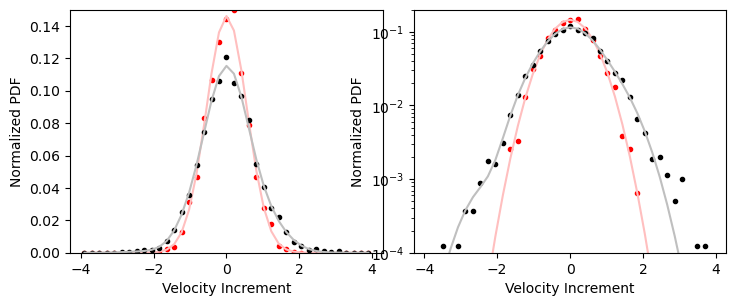

In [14]:
# Plot the PDFs as well as the fit

fig = plt.figure(figsize=Tuple([8, 3]))
ax_dict = fig.subplot_mosaic(
    "AB",
    gridspec_kw=Dict(
        "bottom" => 0.12,
        "top" => 0.93,
        "left" => 0.15,
        "right" => 0.97,
        "wspace" => 0.1,
        "hspace" => 0.4,
    ),
)

# w = [sqrt(d) for d in v_bec_hist_data] ./ 20

# ax_dict["A"].errorbar(v_bec_hist_x, v_bec_hist_data, yerr=w, fmt="r.")
ax_dict["A"].plot(v_bec_hist_x, v_bec_hist_data, "r.")
ax_dict["A"].plot(v_bec_hist_x, gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit)), "-", color=(1.0, 0.75, 0.75))

ax_dict["A"].plot(v_turb_hist_x, v_turb_hist_data, "k.")
ax_dict["A"].plot(v_turb_hist_x, gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit)), "-", color=(0.75, 0.75, 0.75))

ax_dict["A"].set_xlabel("Velocity Increment")
ax_dict["A"].set_ylabel("Normalized PDF")
ax_dict["A"].set_ylim([0, 0.15])

ax_dict["B"].plot(v_bec_hist_x, v_bec_hist_data, "r.")
ax_dict["B"].plot(v_bec_hist_x, gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit)), "-", color=(1.0, 0.75, 0.75))

ax_dict["B"].plot(v_turb_hist_x, v_turb_hist_data, "k.")
ax_dict["B"].plot(v_turb_hist_x, gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit)), "-", color=(0.75, 0.75, 0.75))

ax_dict["B"].set_xlabel("Velocity Increment")
ax_dict["B"].set_ylabel("Normalized PDF")
ax_dict["B"].set_yscale("log")
ax_dict["B"].set_ylim([1e-4, 0.2])

plt.gcf()


In [15]:
reg = 0.01

# Now I will zero pad both data sets

pad = [0.0 for x in v_bec_hist_data]

v_bec_hist_pad = vcat(pad, gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit)), pad) # Use the fit here
v_turb_hist_pad = vcat(pad, gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit)), pad)

# Now I compute the FFT of these

v_bec_hist_fft = FFTW.fft(v_bec_hist_pad)
v_turb_hist_fft = FFTW.fft(v_turb_hist_pad)

conv_fft = v_turb_hist_fft .* v_bec_hist_fft
deconv_fft = v_turb_hist_fft .* conj(v_bec_hist_fft) ./ (reg .+ abs.(v_bec_hist_fft) .^ 2)

conv = FFTW.fftshift(real(FFTW.ifft(conv_fft)))
deconv = FFTW.fftshift(real(FFTW.ifft(deconv_fft)))

# Remove zero-padding
conv = conv[(length(v_bec_hist_data)+1):(2*length(v_bec_hist_data))]
deconv = deconv[(length(v_bec_hist_data)+1):(2*length(v_bec_hist_data))]

sum(deconv)


0.9898670744799187

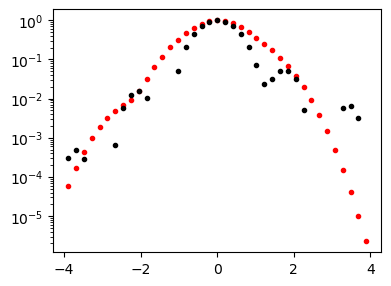

In [16]:
fig = plt.figure(figsize=Tuple([4, 3]))
ax_dict = fig.subplot_mosaic(
    "A",
    gridspec_kw=Dict(
        "bottom" => 0.12,
        "top" => 0.93,
        "left" => 0.15,
        "right" => 0.97,
        "wspace" => 0.1,
        "hspace" => 0.4,
    ),
)

m = gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, m ./ maximum(m), "r.")
ax_dict["A"].plot(v_turb_hist_x, deconv ./ maximum(deconv), "k.")
ax_dict["A"].set_yscale("log")

plt.gcf()


## Now fit to the the deconvolved PDF

The title is a bit unclear.  Here I will be making my fit function perform the convolve operation and fitting to the sort of polynomial model that I used above to fit to the observed PDF.

In [17]:
struct ConvolveGauss{T}
    model::T
    kernel::Vector{Float64}
end

function (a::ConvolveGauss)(y, p; truncate=true)

    # Evaluate model
    m = a.model
    d = m(y, p)

    pad = zero(y)

    # The zero padding doesn't seem to matter 
    # d = vcat(d, pad) 
    # k = vcat(a.kernel, pad)
    k = a.kernel

    # Convolve with kernel
    d_fft = FFTW.fft(d)
    # d_fft = FFTW.fft(FFTW.fftshift(d))
    kernel_fft = FFTW.fft(k) # This can and should be cached
    # kernel_fft = FFTW.fft(FFTW.fftshift(k)) # This can and should be cached
    conv_fft = d_fft .* conj(kernel_fft)
    conv = real(FFTW.fftshift(FFTW.ifft(conv_fft)))

    # if truncate
    #     conv = conv[(length(pad)+1):(length(pad) + length(y))]
    # end

    return conv
    # println(typeof(d), " , ", typeof(a.kernel))
    # return DSP.conv(d, a.kernel)
end

In [45]:
# Fit turbulant data to conv_model
model = Gauss(4)
bec_fit_temp = copy(LsqFit.coef(bec_fit))
# bec_fit_temp[2] = 0.25 # This was testing if changing this caused the recovered peak to move in the correct direction (it did)

conv_model = ConvolveGauss(model, gauss_model_bec(v_bec_hist_x, bec_fit_temp));
# conv_model = ConvolveGauss(model, v_bec_hist_data); # This convolves with the actual data.

p0 = [1.1, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
lb = [0.1, -0.5, 0.01, -1.0, -8, -1, -1]
ub = [10.0, 0.5, 1, 1.0, 5.0, 1, 1.0]

# There are 8776 points in the turb dataset
n = 1.0 / 8776.0
w_turb = [(n * d + 1)^-0.5 for d in v_turb_hist_data] ./ n
turb_fit = LsqFit.curve_fit(conv_model, v_turb_hist_x, v_turb_hist_data, w_turb, p0, lower=lb, upper=ub);
LsqFit.coef(turb_fit)

7-element Vector{Float64}:
  0.2167918263033283
  0.1500616480204709
  0.49367474376294784
 -0.4040402842747608
 -1.532003138513015
  0.19228602275480175
  1.0

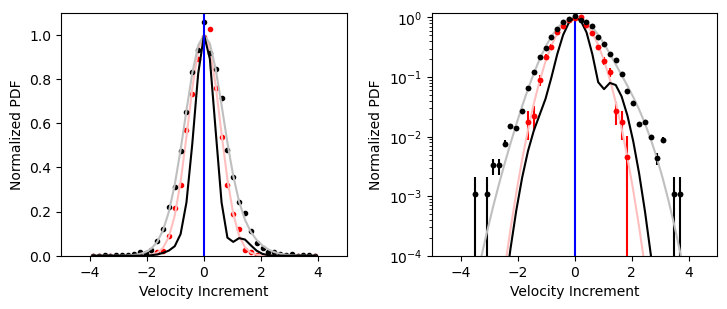

In [46]:
# Plot the PDFs as well as the fit

fig = plt.figure(figsize=Tuple([8, 3]))
ax_dict = fig.subplot_mosaic(
    "AB",
    gridspec_kw=Dict(
        "bottom" => 0.12,
        "top" => 0.93,
        "left" => 0.15,
        "right" => 0.97,
        "wspace" => 0.3,
        "hspace" => 0.4,
    ),
)

m = gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit))

# ax_dict["A"].errorbar(v_bec_hist_x, v_bec_hist_data ./ maximum(m), yerr=(1.0./w_bec)./ maximum(m), fmt="r.")
ax_dict["A"].plot(v_bec_hist_x, v_bec_hist_data ./ maximum(m), "r.")
ax_dict["A"].plot(v_bec_hist_x, m ./ maximum(m), "-", color=(1.0, 0.75, 0.75))

e_bec = (1.0./w_bec) .* [d > 0 ? 1.0 : 0.0 for d in v_bec_hist_data]
ax_dict["B"].errorbar(v_bec_hist_x, v_bec_hist_data ./ maximum(m), yerr=e_bec ./ maximum(m), fmt="r.")
ax_dict["B"].plot(v_bec_hist_x, v_bec_hist_data ./ maximum(m), "r.")
ax_dict["B"].plot(v_bec_hist_x, m ./ maximum(m), "-", color=(1.0, 0.75, 0.75))

m = conv_model(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, v_turb_hist_data ./ maximum(m) , "k.")
ax_dict["A"].plot(v_turb_hist_x, m ./ maximum(m) , "-", color=(0.75, 0.75, 0.75))

e_turb = (1.0./w_turb) .* [d > 0 ? 1.0 : 0.0 for d in v_turb_hist_data]
ax_dict["B"].errorbar(v_turb_hist_x, v_turb_hist_data ./ maximum(m), yerr=e_turb ./ maximum(m), fmt="k.")
ax_dict["B"].plot(v_turb_hist_x, v_turb_hist_data ./ maximum(m) , "k.")
ax_dict["B"].plot(v_turb_hist_x, m ./ maximum(m) , "-", color=(0.75, 0.75, 0.75))

m = model(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, model(v_turb_hist_x, LsqFit.coef(turb_fit)) ./ maximum(m), "-", color="k")
ax_dict["B"].plot(v_turb_hist_x, model(v_turb_hist_x, LsqFit.coef(turb_fit)) ./ maximum(m), "-", color="k")


ax_dict["A"].set_xlabel("Velocity Increment")
ax_dict["B"].set_xlabel("Velocity Increment")

ax_dict["A"].set_ylabel("Normalized PDF")
ax_dict["B"].set_ylabel("Normalized PDF")

ax_dict["A"].axvline(0.0, color="b")
ax_dict["B"].axvline(0.0, color="b")


# ax_dict["A"].set_xlim([-1.5, 1.5])
ax_dict["B"].set_yscale("log")

ax_dict["A"].set_ylim([0, 1.1])
ax_dict["B"].set_ylim([1e-4, 1.2])


ax_dict["A"].set_xlim([-5,5])
ax_dict["B"].set_xlim([-5, 5])

plt.gcf()


## Understand Histograms vs convolutions

Mingshu was attempting to convolve and deconvolve the numerically simulated data and was unable to recover the initial distribution.  I wonder what is going on here so I will do some numerical experiments similar to his.  The first thing I will do is to generate data sampled from known distributions and model what the measured histograms might look like.

First I will take simple normal distributions as ground truth.

In [21]:
"""
Returns a sample from a distribution defined by a cdf
"""
function sample(cdf, x_grid)
    y = rand()
    # we find the index of the cdf that is most close to yerr

    idx = argmin(abs.(cdf .- y))
    return x_grid[idx]
end

"""
Generates a histogram
"""
function hist(data, x_grid)
    ans  = zero(x_grid)

    for d in data
        idx = argmin(abs.(x_grid .- d))
        ans[idx] += 1
    end

    return ans
end

hist

In [22]:
# Generate the ground truth distributions
v_points = 1024 # Number of points in the distributions
v_max = 5 # how far out to sample
v_grid = -v_max:(2*v_max / v_points):v_max 

pdf_turb = model(v_grid, LsqFit.coef(turb_fit))
cdf_turb = cumsum(pdf_turb)
cdf_turb /= cdf_turb[end]

pdf_bec = gauss_model_bec(v_grid, LsqFit.coef(bec_fit))
cdf_bec = cumsum(pdf_bec)
cdf_bec /= cdf_bec[end]

sample(cdf_bec, v_grid)


0.517578125

In [23]:
# Generate ground truth, noise, and add to get measurement outcomes.

samples = 8776 # nummber of samples to Generate

measure_turb = [sample(cdf_turb, v_grid) for _ in 1:samples]
measure_bec = [sample(cdf_bec, v_grid) for _ in 1:samples]
measure_raw = measure_turb .+ measure_bec

hist_turb = hist(measure_turb, v_turb_hist_x)
hist_turb ./= maximum(hist_turb)

hist_bec = hist(measure_bec, v_bec_hist_x)
hist_bec ./= maximum(hist_bec);

hist_raw = hist(measure_raw, v_turb_hist_x)
hist_raw ./= maximum(hist_raw);


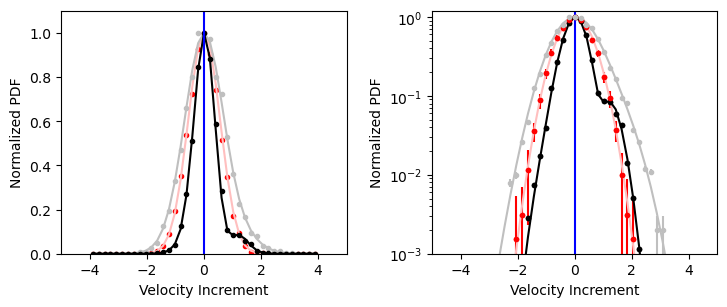

In [24]:
# Plot the PDFs as well as the fit

fig = plt.figure(figsize=Tuple([8, 3]))
ax_dict = fig.subplot_mosaic(
    "AB",
    gridspec_kw=Dict(
        "bottom" => 0.12,
        "top" => 0.93,
        "left" => 0.15,
        "right" => 0.97,
        "wspace" => 0.3,
        "hspace" => 0.4,
    ),
)

m = gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit))

ax_dict["A"].plot(v_bec_hist_x, hist_bec, "r.")
ax_dict["A"].plot(v_bec_hist_x, m ./ maximum(m), "-", color=(1.0, 0.75, 0.75))

e_bec = (1.0./w_bec) .* [d > 0 ? 1.0 : 0.0 for d in hist_bec]
ax_dict["B"].errorbar(v_bec_hist_x, hist_bec, yerr=e_bec ./ maximum(m), fmt="r.")
ax_dict["B"].plot(v_bec_hist_x, hist_bec, "r.")
ax_dict["B"].plot(v_bec_hist_x, m ./ maximum(m), "-", color=(1.0, 0.75, 0.75))

m = conv_model(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, hist_raw, ".", color=(0.75, 0.75, 0.75))
ax_dict["A"].plot(v_turb_hist_x, m ./ maximum(m) , "-", color=(0.75, 0.75, 0.75))

e_turb = (1.0./w_turb) .* [d > 0 ? 1.0 : 0.0 for d in hist_raw]
ax_dict["B"].errorbar(v_turb_hist_x, hist_raw, yerr=e_turb ./ maximum(m), fmt=".", color=(0.75, 0.75, 0.75))
ax_dict["B"].plot(v_turb_hist_x, m ./ maximum(m) , "-", color=(0.75, 0.75, 0.75))

ax_dict["B"].plot(v_turb_hist_x, hist_turb, "k.")

m = model(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, hist_turb, "k.")
ax_dict["B"].plot(v_turb_hist_x, hist_turb, "k.")

ax_dict["A"].plot(v_turb_hist_x, model(v_turb_hist_x, LsqFit.coef(turb_fit)) ./ maximum(m), "-", color="k")
ax_dict["B"].plot(v_turb_hist_x, model(v_turb_hist_x, LsqFit.coef(turb_fit)) ./ maximum(m), "-", color="k")


ax_dict["A"].set_xlabel("Velocity Increment")
ax_dict["B"].set_xlabel("Velocity Increment")

ax_dict["A"].set_ylabel("Normalized PDF")
ax_dict["B"].set_ylabel("Normalized PDF")

ax_dict["A"].axvline(0.0, color="b")
ax_dict["B"].axvline(0.0, color="b")


# ax_dict["A"].set_xlim([-1.5, 1.5])
ax_dict["B"].set_yscale("log")

ax_dict["A"].set_ylim([0, 1.1])
ax_dict["B"].set_ylim([1e-3, 1.2])


ax_dict["A"].set_xlim([-5,5])
ax_dict["B"].set_xlim([-5, 5])

plt.gcf()


This already shows the worrying effect: My samples did a good job of drawing from the target distributions (black and red), but summing them did not result in the function that is supposed to be the convolution of the two!!

Note that Mingshu finds that the final distribution is shifted by 1/2 a grid point.  I now think this is an Fourier issue associated with having an even number of points...

Once shift is sorted out then try the whole analysis with gaussian data.